# 注意力机制

## 第一章：你的大语言模型之旅第三站——注意力机制

### 准备工作：导入我们的工具箱

In [3]:
# 导入torch库，这是我们的核心工具
import torch
import torch.nn as nn
from importlib.metadata import version

print("torch version:", version("torch"))

torch version: 2.5.1


## 第二章：最简单的“注意力”——没有学分的举手

### 2.1 准备舞台：创建示例数据

In [4]:
# 假设的输入数据：一个句子，6个词，每个词用一个3维向量表示
# 每一行代表一个词的嵌入向量
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

print("输入张量形状:", inputs.shape) # 6个词，每个3维
print("输入张量:\n", inputs)

输入张量形状: torch.Size([6, 3])
输入张量:
 tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])


### 2.2 第一步：计算“关注分数”（点积）

要理解“注意力”，我们得先有个分数来衡量词与词之间的相关性。最直接的方法就是计算它们向量之间的点积。点积越大，两个向量方向越一致，相关性越高。

现在我们以第二个词 journey 作为“查询”，看看它和其他所有词（包括自己）有多相关。



In [5]:
# 选择第二个词 x^(2) "journey" 作为我们的查询
query = inputs[1]  
print("查询向量 'journey':", query)

# 创建一个长度为6的空张量，用来存放journey和其他6个词的相关性分数
attn_scores_2 = torch.empty(inputs.shape[0])

# 循环计算journey和每个词的点积
for i, x_i in enumerate(inputs):
    # torch.dot() 计算两个向量的点积
    attn_scores_2[i] = torch.dot(x_i, query)

print("\njourney与所有词的原始关注分数:", attn_scores_2)

查询向量 'journey': tensor([0.5500, 0.8700, 0.6600])

journey与所有词的原始关注分数: tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


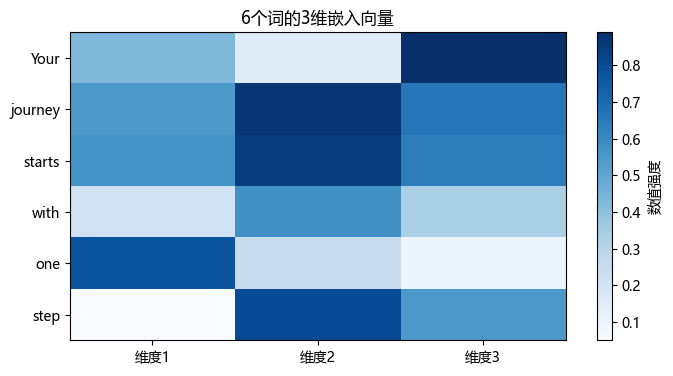

In [7]:
import torch
import matplotlib.pyplot as plt

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your
   [0.55, 0.87, 0.66], # journey
   [0.57, 0.85, 0.64], # starts
   [0.22, 0.58, 0.33], # with
   [0.77, 0.25, 0.10], # one
   [0.05, 0.80, 0.55]] # step
)

words = ['Your', 'journey', 'starts', 'with', 'one', 'step']
# # 设置中文字体（如果需要）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 4))
plt.imshow(inputs.numpy(), cmap='Blues', aspect='auto')
plt.xticks([0,1,2], ['维度1', '维度2', '维度3'])
plt.yticks(range(6), words)
plt.colorbar(label='数值强度')
plt.title('6个词的3维嵌入向量')
plt.show()